<a href="https://colab.research.google.com/github/rakshitpanwar/hybrid-cnn-anfis-forgery-detection/blob/main/notebooks/hybrid_cnn_anfis_forgery_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

os.environ['KAGGLE_TOKEN'] = userdata.get('KAGGLE_TOKEN')

!kaggle datasets download -d shreelakshmigp/cedardataset -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/shreelakshmigp/cedardataset
License(s): unknown
100% 242M/242M [00:18<00:00, 14.1MB/s]



In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from skimage.morphology import skeletonize
import seaborn as sns

# dataset paths
GENUINE_DIR = '/content/data/signatures/full_org'
FORGED_DIR  = '/content/data/signatures/full_forg'

# image settings
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
EPOCHS      = 20

print("All imports successful")
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

All imports successful
TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
def preprocess_image(img_path, size=IMG_SIZE, thin=True):
    # read as grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None  # skip unreadable files

    # noise removal
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # binarization - Otsu's method
    _, img = cv2.threshold(img, 0, 255,
                           cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # resize to fixed shape
    img = cv2.resize(img, size)

    # stroke thinning (skeletonize)
    if thin:
        img = (skeletonize(img // 255) * 255).astype(np.uint8)

    # normalize to [0, 1]
    img = img / 255.0

    return img.reshape(size[0], size[1], 1)  # add channel dim


print("Preprocessing function defined")

Preprocessing function defined


In [4]:
X = []  # images
y = []  # labels: 1 = genuine, 0 = forged

# load genuine signatures
for fname in os.listdir(GENUINE_DIR):
    if not fname.endswith('.png'):
        continue
    path = os.path.join(GENUINE_DIR, fname)
    img  = preprocess_image(path)
    if img is not None:
        X.append(img)
        y.append(1)

# load forged signatures
for fname in os.listdir(FORGED_DIR):
    if not fname.endswith('.png'):
        continue
    path = os.path.join(FORGED_DIR, fname)
    img  = preprocess_image(path)
    if img is not None:
        X.append(img)
        y.append(0)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print(f"Total samples:  {len(X)}")
print(f"Genuine (1):    {np.sum(y == 1)}")
print(f"Forged  (0):    {np.sum(y == 0)}")
print(f"Image shape:    {X[0].shape}")

Total samples:  2640
Genuine (1):    1320
Forged  (0):    1320
Image shape:    (128, 128, 1)


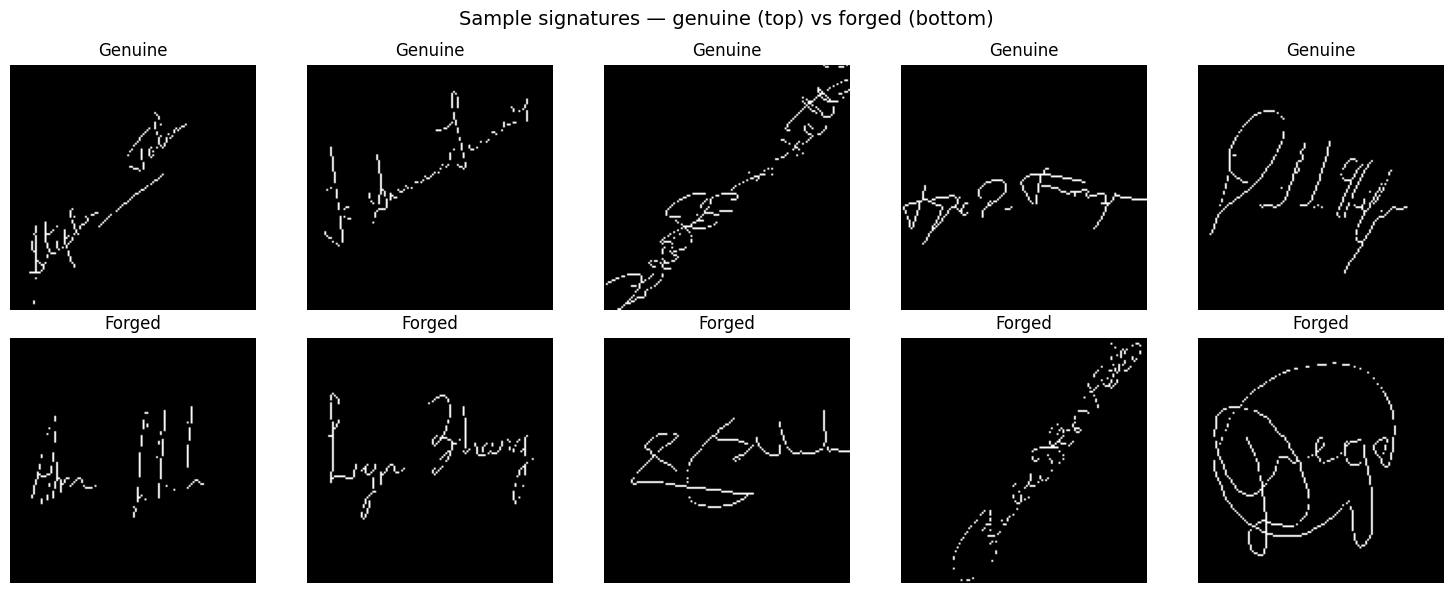

Saved as sample_signatures.png


In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample signatures — genuine (top) vs forged (bottom)',
             fontsize=14)

genuine_indices = np.where(y == 1)[0][:5]
forged_indices  = np.where(y == 0)[0][:5]

for i, idx in enumerate(genuine_indices):
    axes[0, i].imshow(X[idx].squeeze(), cmap='gray')
    axes[0, i].set_title('Genuine')
    axes[0, i].axis('off')

for i, idx in enumerate(forged_indices):
    axes[1, i].imshow(X[idx].squeeze(), cmap='gray')
    axes[1, i].set_title('Forged')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('sample_signatures.png', dpi=150)
plt.show()
print("Saved as sample_signatures.png")

In [6]:
# first split off test set (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

# split remaining into train (80%) and val (10%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)} samples")
print(f"Val:   {len(X_val)} samples")
print(f"Test:  {len(X_test)} samples")

Train: 2112 samples
Val:   264 samples
Test:  264 samples


In [7]:
def build_cnn(input_shape=(128, 128, 1)):
    model = keras.Sequential([

        # block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # feature vector
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        # output
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,129 (16.36 MB)

 Trainable params: 4,287,681 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# callbacks
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, verbose=1
)

# train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("Training complete")

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.6070 - loss: 2.1027 - val_accuracy: 0.5000 - val_loss: 4.5456 - learning_rate: 0.0010
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6913 - loss: 0.5738 - val_accuracy: 0.5000 - val_loss: 4.2430 - learning_rate: 0.0010
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6993 - loss: 0.5407 - val_accuracy: 0.3447 - val_loss: 1.9414 - learning_rate: 0.0010
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7154 - loss: 0.5200 - val_accuracy: 0.4848 - val_loss: 2.7817 - learning_rate: 0.0010
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7372 - loss: 0.4885 - val_accuracy: 0.5114 - val_loss: 1.6258 - learning_rate: 0.0010
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7524 - loss: 0.4674 - val_accuracy: 0.5038 - val_loss: 1.3880 - learning_rate: 0.0010
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7874 - loss: 0.4073 - val_ac

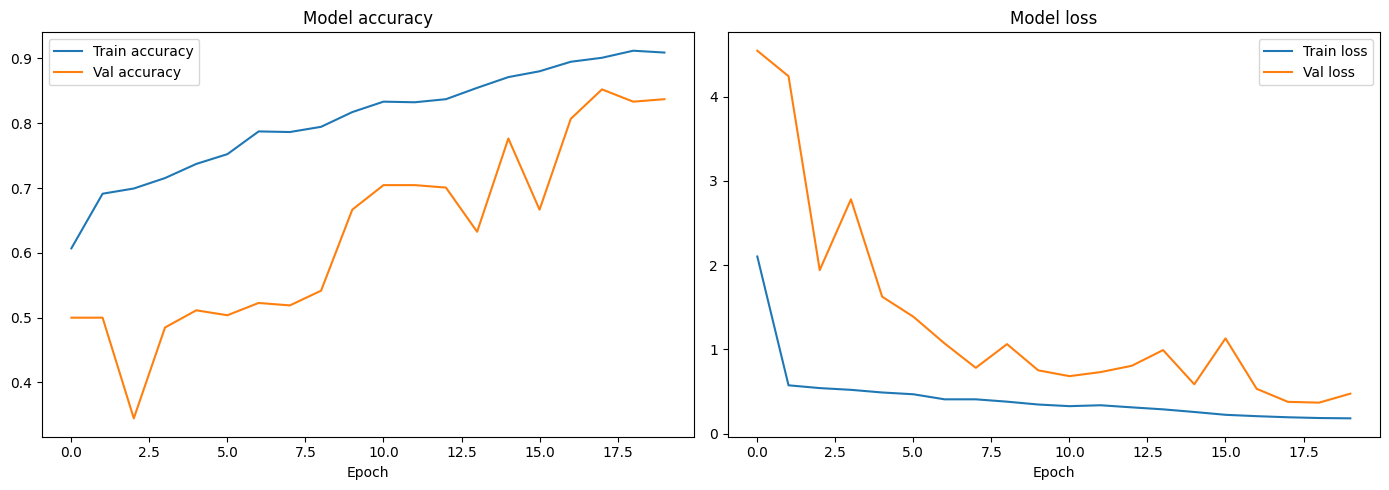

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# accuracy
axes[0].plot(history.history['accuracy'],     label='Train accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val accuracy')
axes[0].set_title('Model accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# loss
axes[1].plot(history.history['loss'],     label='Train loss')
axes[1].plot(history.history['val_loss'], label='Val loss')
axes[1].set_title('Model loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 362ms/step
              precision    recall  f1-score   support

      Forged       0.90      0.84      0.87       132
     Genuine       0.85      0.91      0.88       132

    accuracy                           0.88       264
   macro avg       0.88      0.88      0.87       264
weighted avg       0.88      0.88      0.87       264



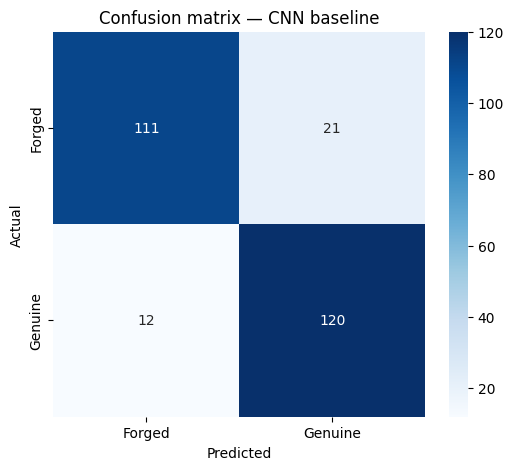

In [10]:
# predictions
y_pred_prob = model.predict(X_test)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

# classification report
print(classification_report(y_test, y_pred,
      target_names=['Forged', 'Genuine']))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Forged','Genuine'],
            yticklabels=['Forged','Genuine'])
plt.title('Confusion matrix — CNN baseline')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix_cnn.png', dpi=150)
plt.show()

In [11]:
model.save('models/cnn_baseline.h5')
print("Model saved")

Model saved
